In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
medical_data = pd.read_csv('medical_examination.csv')
medical_data.head(20)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0


In [3]:
medical_data["Overweight"] = medical_data["weight"] / ((medical_data["height"] / 100) ** 2)

medical_data["Overweight"] = (medical_data['Overweight'] > 25).astype(int)

medical_data.head(20)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,Overweight
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0,1
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0,1
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0,1
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0,1


In [4]:
medical_data[['cholesterol', 'gluc']] = medical_data[['cholesterol', 'gluc']].map(lambda x: 0 if x == 1 else 1)

medical_data.head(20)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,Overweight
0,0,18393,2,168,62.0,110,80,0,0,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,1,0,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,1,0,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,0,0,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,0
5,8,21914,1,151,67.0,120,80,1,1,0,0,0,0,1
6,9,22113,1,157,93.0,130,80,1,0,0,0,1,0,1
7,12,22584,2,178,95.0,130,90,1,1,0,0,1,1,1
8,13,17668,1,158,71.0,110,70,0,0,0,0,1,0,1
9,14,19834,1,164,68.0,110,60,0,0,0,0,0,0,1


## When not to melt:

- If you're only using two features at a time for analysis or visualization (like comparing one variable against another), you can leave the data in its wide format.

- You don’t need to stack the columns into one, because you’re only concerned with those two specific features.<br><br>

## When to melt:

If you want to analyze or visualize multiple features collectively or compare them against each other in one plot (like comparing cholesterol, gluc, active, and smoke across cardio status), melting is useful.

Melt will stack those features into a single column, making it easier to group or visualize them together.

In this case, melting helps by combining all the health indicators into one column (variable), making it easier to show counts or distributions of each one across different categories.

Why melt for multiple features?
Stacking the features into one column allows you to group them by the same categorical column (e.g., cardio) and then easily compare them in a unified analysis or plot.
Simplifies the process of analyzing or plotting categories across multiple variables without having to deal with each column separately.

        cardio variable  value
0            0   active      1
1            1   active      1
2            1   active      0
3            1   active      1
4            0   active      0
...        ...      ...    ...
419995       0    smoke      1
419996       1    smoke      0
419997       1    smoke      0
419998       1    smoke      0
419999       0    smoke      0

[420000 rows x 3 columns]


    cardio     variable  value  total
0        0   Overweight      0  15915
1        0   Overweight      1  19106
2        0       active      0   6378
3        0       active      1  28643
4        0         alco      0  33080
5        0         alco      1   1941
6        0  cholesterol      0  29330
7        0  cholesterol      1   5691
8        0         gluc      0  30894
9        0         gluc      1   4127
10       0        smoke      0  31781
11       0        smoke      1   3240
12       1   Overweight      0  10539
13       1   Overweight      1  24440
14       1       active      

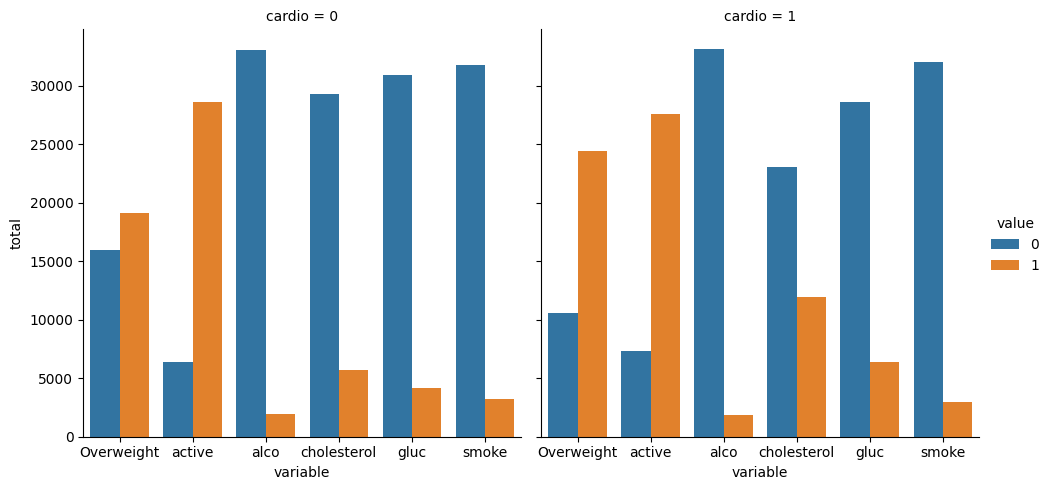

In [ ]:
def draw_cat_plot():

  columns = [
    'active',
    'alco',
    'cholesterol',
    'gluc',
    'Overweight',
    'smoke'
  ]

  medicall_data_cat = pd.melt(medical_data,
                              id_vars=['cardio'],
                              value_vars=columns, 
                              var_name='variable', 
                              value_name='value')   # Column name for corresponding values)
  
  print(medicall_data_cat)
  print("\n")

  
  medicall_data_cat = medicall_data_cat.groupby(['cardio', 'variable', 'value']).size().reset_index(name='total')

  print(medicall_data_cat.head(20))
  print("\n")

  sns.catplot(
      data=medicall_data_cat, 
      x='variable', 
      y='total', 
      hue='value',  # Different colors for different categorical values
      kind='bar', 
      col='cardio',  # Separate plots for cardio = 0 and cardio = 1
  )


  plt.show()


draw_cat_plot()

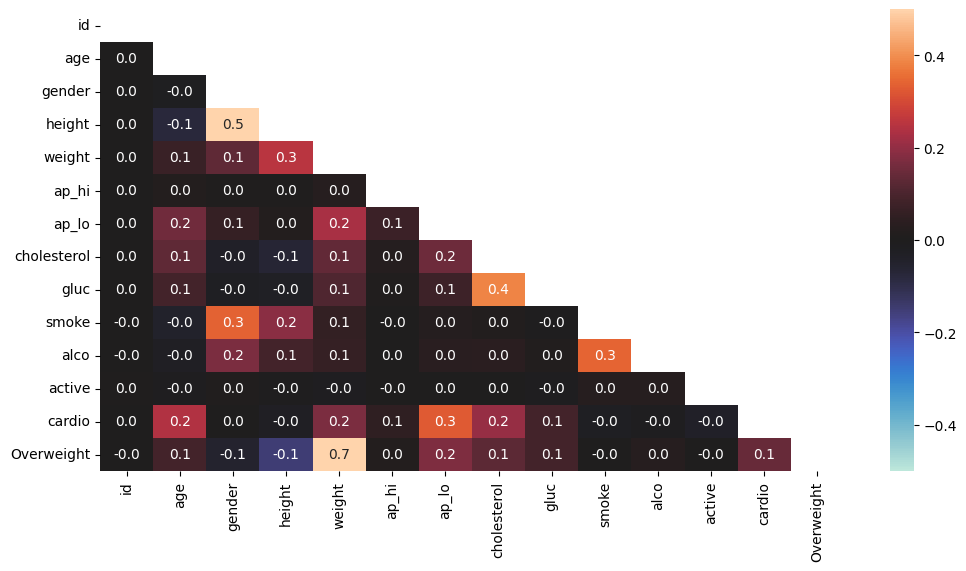

In [ ]:
def draw_heat_map():
    # Clean the data
    # - diastolic pressure is higher then systolic
    # - height is less than the 2.5th percentile
    # - height is more than the 97.5th percentile
    # - weight is less then the 2.5th percentile
    # - weight is more than the 97.5th percentile
    medical_data_heat = medical_data[
      (medical_data['ap_lo'] <= medical_data['ap_hi'])
      & (medical_data['height'] >= medical_data['height'].quantile(0.025))
      & (medical_data['height'] <= medical_data['height'].quantile(0.975))
      & (medical_data['weight'] >= medical_data['weight'].quantile(0.025))
      & (medical_data['weight'] <= medical_data['weight'].quantile(0.975))
    ]


    corr = medical_data_heat.corr()


    mask = np.zeros_like(corr)
    mask[np.triu_indices_from(mask)] = True

    fig = plt.figure(figsize=(12,6))


    sns.heatmap(corr, mask=mask,
                annot=True, fmt='.1f',
                center=0, vmin=-0.5, vmax=0.5)
    

draw_heat_map()
